In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\ev_charging_cleaned.csv")

df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Transaction Date (Pacific Time)'] = pd.to_datetime(df['Transaction Date (Pacific Time)'])

df['Total Duration (hh:mm:ss)'] = pd.to_timedelta(df['Total Duration (hh:mm:ss)'])

df['Charging Time (hh:mm:ss)'] = pd.to_timedelta(df['Charging Time (hh:mm:ss)'])

df['Start Date Year'] = pd.to_datetime(df['Start Date']).dt.year
df['Start Date Month'] = pd.to_datetime(df['Start Date']).dt.month
df['Start Date Date'] = pd.to_datetime(df['Start Date']).dt.date
df['Start Date Hour'] = pd.to_datetime(df['Start Date']).dt.hour
df['Start Date Dayofweek'] = pd.to_datetime(df['Start Date']).dt.dayofweek
df['Start Date is weekend'] = (pd.to_datetime(df['Start Date']).dt.dayofweek >= 5).astype(int)
df['Start Date quarter'] = pd.to_datetime(df['Start Date']).dt.quarter

station_day=df.groupby(['Station Name','Start Date Date']).agg({'Start Date':'count', 'Energy (kWh)':['sum','mean'],'Total Duration (hh:mm:ss)':'mean','Charging Time (hh:mm:ss)':'mean'})

station_day.columns = [
    'sessions_count',
    'total_energy',
    'avg_energy',
    'avg_total_duration',
    'avg_charging_time'
]

station_day.reset_index(inplace=True)

station_day['Start Date Date'] = pd.to_datetime(station_day['Start Date Date'])

station_day['avg_charging_time'] = (station_day['avg_charging_time'].dt.total_seconds() / 3600)

station_day['avg_total_duration'] = (station_day['avg_total_duration'].dt.total_seconds() / 3600)

station_day['Overload']=np.where(station_day['sessions_count']>= 11, 1, 0)

station_day['Start Date Month'] = station_day['Start Date Date'].dt.month
station_day['Start Date Dayofweek'] = station_day['Start Date Date'].dt.dayofweek
station_day['Start Date is weekend'] = (pd.to_datetime(station_day['Start Date Date']).dt.dayofweek >= 5).astype(int)
station_day['Start Date quarter'] = station_day['Start Date Date'].dt.quarter

station_day.sort_values(by=['Station Name','Start Date Date'],inplace=True)

station_day['lag_1_sessions']=station_day.groupby('Station Name')['sessions_count'].shift(1)
station_day['lag_7_sessions']=station_day.groupby('Station Name')['sessions_count'].shift(7)

station_day['rolling_7_mean'] = station_day.groupby('Station Name')['sessions_count'].shift(1).transform(lambda x: x.rolling(7).mean())
station_day['rolling_7_std'] = station_day.groupby('Station Name')['sessions_count'].shift(1).transform(lambda x: x.rolling(7).std())

station_day.dropna(inplace=True)

print(station_day.shape)
station_day.sort_values(by=['Start Date Date'], inplace=True)

X=station_day.drop(columns=['Station Name','Start Date Date','sessions_count','Overload','total_energy','avg_energy','avg_total_duration','avg_charging_time'])
y=station_day['Overload']

print(X.shape)
print(y.shape)

X.to_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\X.csv", index=False)
y.to_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\y.csv", index=False)

print(X.columns)


C:\Users\loneo\AppData\Local\Temp\ipykernel_18596\2968050010.py:1: DtypeWarning: Columns (0: User ID, 1: County, 2: Model Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\ev_charging_cleaned.csv")


(55004, 16)
(55004, 8)
(55004,)
Index(['Start Date Month', 'Start Date Dayofweek', 'Start Date is weekend',
       'Start Date quarter', 'lag_1_sessions', 'lag_7_sessions',
       'rolling_7_mean', 'rolling_7_std'],
      dtype='str')


In [3]:
!pip install shap


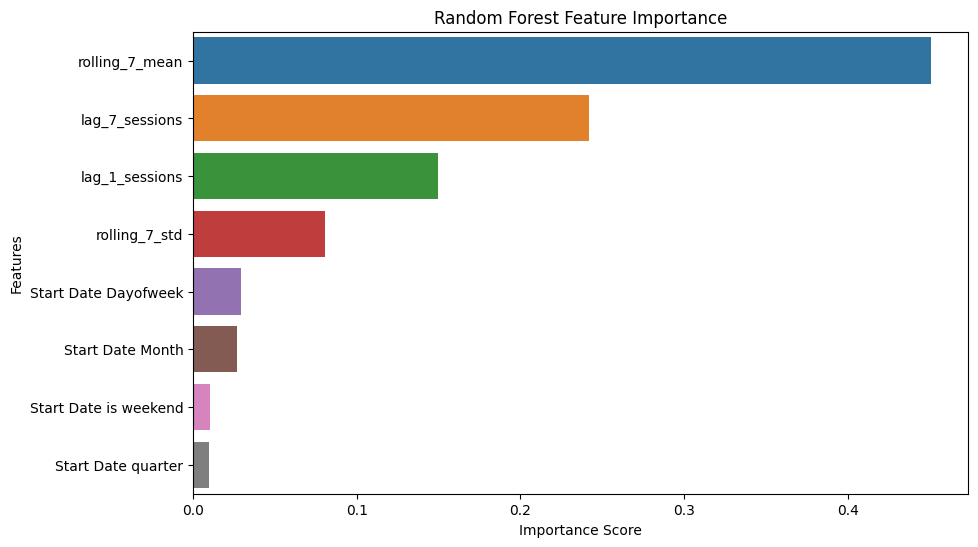

In [4]:

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats




model_path = r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\model\rf_tuned_model.joblib"
x_path = r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\X.csv"
y_path = r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\y.csv"


rf_final = joblib.load(model_path)


X = pd.read_csv(x_path)
y = pd.read_csv(y_path)


importances = rf_final.feature_importances_
feature_names = X.columns


importance_df = pd.DataFrame({'Feature': feature_names,'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))


sns.barplot(x='Importance', y='Feature', data=importance_df)


plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")



plt.show()


Historical usage patterns (like rolling means and lag sessions) are the strongest drivers of overload events.
Calendar variables (like day of the week or month) contribute much less to predicting an overload.
Selection deleted


In [10]:

weekend_data = station_day[station_day['Start Date is weekend'] == 1]['sessions_count']
weekday_data = station_day[station_day['Start Date is weekend'] == 0]['sessions_count']

#  Mann-Whitney U Test
stat1, p1 = stats.mannwhitneyu(weekday_data, weekend_data, alternative='two-sided')


print("H0: Demand (sessions_count) is the same on weekends and weekdays.")
print("H1: Demand (sessions_count) differs between weekends and weekdays.\n")


print("Test Used : Mann-Whitney U Test")
print("U-Statistic:", stat1)
print("P-Value:", p1)


#  p-value
print("Interpretation:")
if p1 < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis (H0).")
    print("There is a statistically significant difference in demand between weekends and weekdays.")
else:
    print("Since the p-value is greater than or equal to 0.05, we fail to reject the null hypothesis (H0).")
    print("There is no statistically significant difference in demand between weekends and weekdays.")



# 1. Isolate the two groups
overload_data = station_day[station_day['Overload'] == 1]['rolling_7_mean']
non_overload_data = station_day[station_day['Overload'] == 0]['rolling_7_mean']

# 2. Mann-Whitney U Test
stat2, p2 = stats.mannwhitneyu(overload_data, non_overload_data, alternative='two-sided')

print("H0: The rolling_7_mean is the same for Overload and Non-Overload events.")
print("H1: The rolling_7_mean differs between Overload and Non-Overload events.\n")


print("Test Used : Mann-Whitney U Test")
print("U-Statistic:", stat2)
print("P-Value:", p2)
print("")


print("Interpretation:")
if p2 < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis (H0).")
    print("As expected, there is a statistically significant difference in the rolling 7-day mean between Overload and Non-Overload groups.")
else:
    print("Since the p-value is greater than or equal to 0.05, we fail to reject the null hypothesis (H0).")
    print("There is no statistically significant difference between the groups.")

H0: Demand (sessions_count) is the same on weekends and weekdays.
H1: Demand (sessions_count) differs between weekends and weekdays.

Test Used : Mann-Whitney U Test
U-Statistic: 363258215.0
P-Value: 1.519746445238169e-271
Interpretation:
Since the p-value is less than 0.05, we reject the null hypothesis (H0).
There is a statistically significant difference in demand between weekends and weekdays.
H0: The rolling_7_mean is the same for Overload and Non-Overload events.
H1: The rolling_7_mean differs between Overload and Non-Overload events.

Test Used : Mann-Whitney U Test
U-Statistic: 105883039.5
P-Value: 0.0

Interpretation:
Since the p-value is less than 0.05, we reject the null hypothesis (H0).
As expected, there is a statistically significant difference in the rolling 7-day mean between Overload and Non-Overload groups.
